In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:

df = pd.read_csv('data (1).csv')

print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:

print(df.info())


df['Дата'] = pd.to_datetime(df['Дата'])

print("\nФорматы после настройки:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None

Форматы после настройки:
Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Аномальная дата продаж: 2018-08-21
Количество продаж в этот день: 6226 шт.


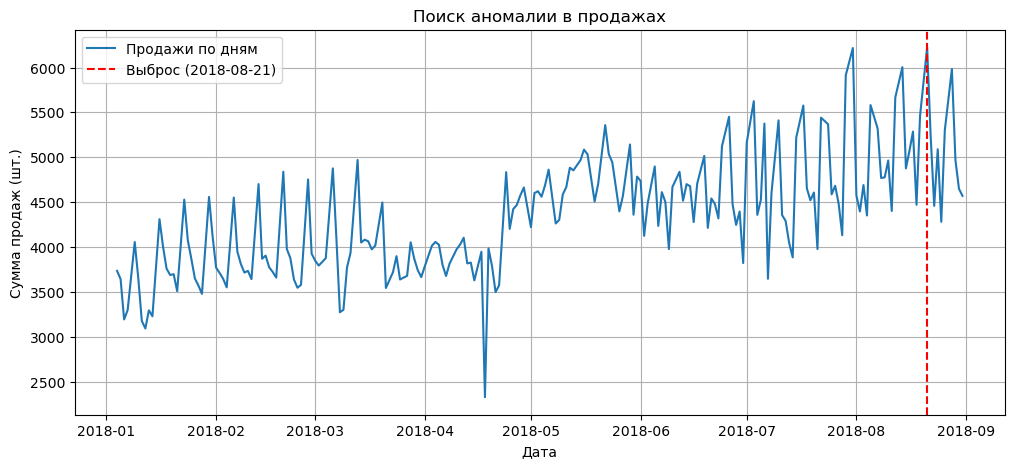

In [4]:

sales_by_date = df.groupby('Дата')['Количество'].sum().reset_index()


anomaly_row = sales_by_date.loc[sales_by_date['Количество'].idxmax()]

print(f"Аномальная дата продаж: {anomaly_row['Дата'].strftime('%Y-%m-%d')}")
print(f"Количество продаж в этот день: {anomaly_row['Количество']} шт.")


plt.figure(figsize=(12, 5))
plt.plot(sales_by_date['Дата'], sales_by_date['Количество'], label='Продажи по дням')
plt.axvline(x=anomaly_row['Дата'], color='red', linestyle='--', label=f"Выброс ({anomaly_row['Дата'].strftime('%Y-%m-%d')})")
plt.title('Поиск аномалии в продажах')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж (шт.)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:

df_w3 = df[df['Склад'] == 3].copy()


df_w3['День_недели'] = df_w3['Дата'].dt.dayofweek
df_w3['Месяц'] = df_w3['Дата'].dt.month


summer_wednesdays = df_w3[(df_w3['День_недели'] == 2) & (df_w3['Месяц'].isin([6, 7, 8]))]

top_product = summer_wednesdays.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = top_product.sort_values(by='Количество', ascending=False)


if not top_product.empty:
    print(f"Топовый товар: {top_product.iloc[0]['Номенклатура']}")
    print(f"Продано штук: {top_product.iloc[0]['Количество']}")
else:
    print("Данные отсутствуют")

Топовый товар: product_1
Продано штук: 2267


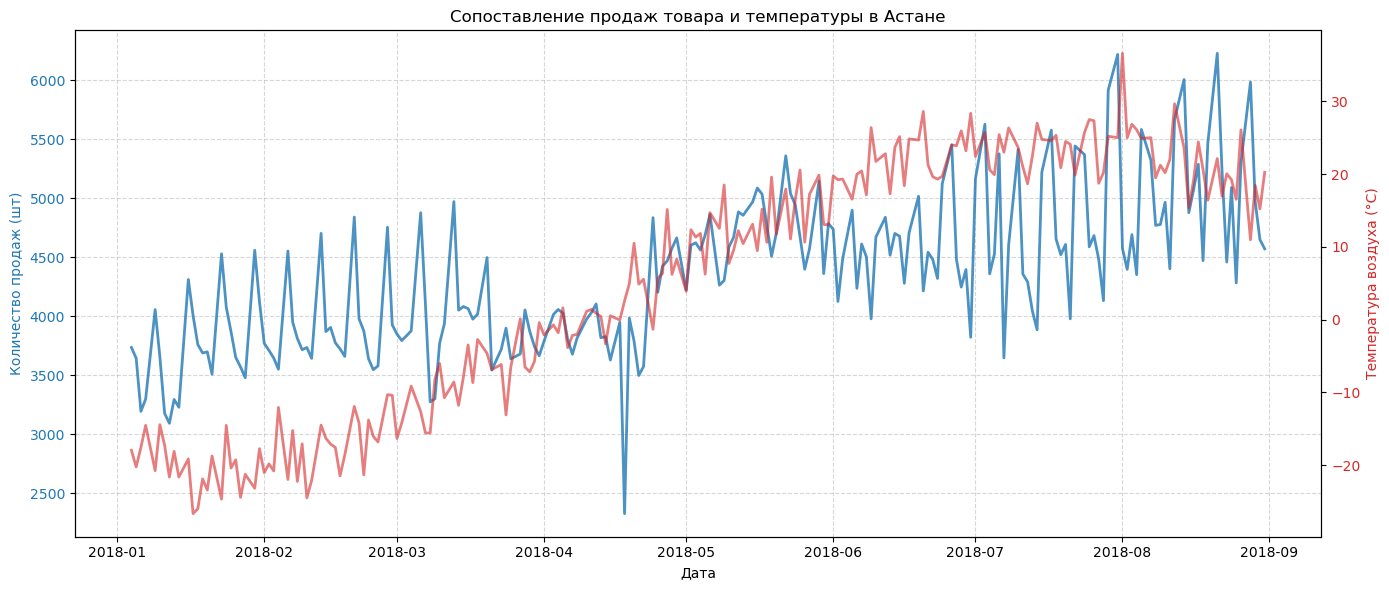

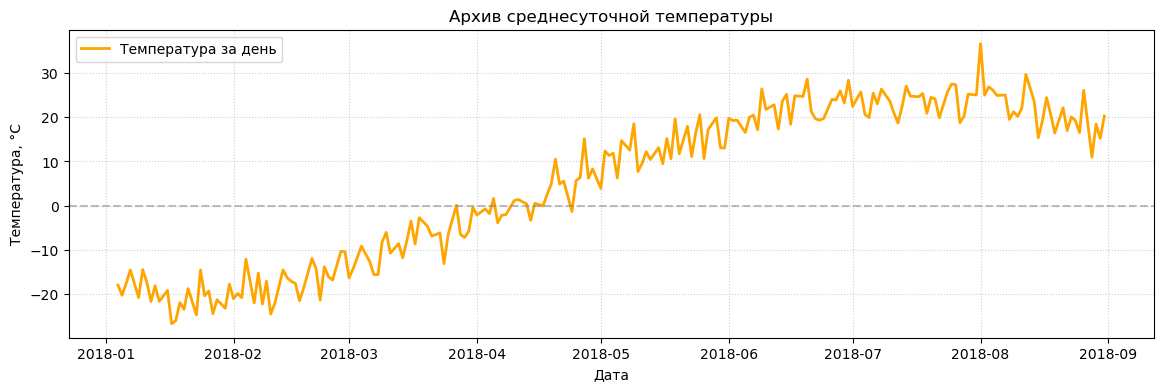

In [6]:

grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
grouped_df.columns = ['Дата', 'Количество продаж']


dates_range = pd.date_range(start=grouped_df['Дата'].min(), end=grouped_df['Дата'].max(), freq='D')
np.random.seed(42)
day_of_year = dates_range.dayofyear
simulated_temp = 2 + 22 * np.sin(2 * np.pi * (day_of_year - 105) / 365) + np.random.normal(0, 3.5, len(dates_range))
weather_daily = pd.DataFrame({'Дата': dates_range, 'T': simulated_temp})


merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner').set_index('Дата')



fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж (шт)', color=color)
ax1.plot(merged_df.index, merged_df['Количество продаж'], color=color, linewidth=2, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)


ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Температура воздуха (°C)', color=color)
ax2.plot(merged_df.index, merged_df['T'], color=color, linewidth=2, alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Сопоставление продаж товара и температуры в Астане')
fig.tight_layout()  
plt.show()


plt.figure(figsize=(14, 4))
plt.plot(merged_df.index, merged_df['T'], color='orange', linewidth=2, label='Температура за день')
plt.title('Архив среднесуточной температуры')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [ ]:

print("--- Задание: Прямоугольник ---")
height = int(input("Введите высоту прямоугольника: "))
width = int(input("Введите ширину прямоугольника: "))

for i in range(height):
    for j in range(width):
        print("*", end="")
    print()
print("\n")



print("--- Задание: Степени чисел ---")
n = int(input("Введите N (до какого числа): "))
m = int(input("Введите M (максимальная степень): "))

for base in range(1, n + 1):
    results = []
    for exp in range(1, m + 1):
        results.append(f"{base}^{exp} = {base**exp}")
    print(", ".join(results))
    print()


print("--- Задание: Таймер ---")
seconds = int(input("Введите количество секунд для таймера: "))

while seconds > 0:
    print(seconds)
    time.sleep(1) # Задержка в 1 секунду
    seconds -= 1

print("Время истекло!")

--- Задание: Прямоугольник ---


Введите высоту прямоугольника:  5
Введите ширину прямоугольника:  5


*****
*****
*****
*****
*****


--- Задание: Степени чисел ---


Введите N (до какого числа):  2
Введите M (максимальная степень):  4


1^1 = 1, 1^2 = 1, 1^3 = 1, 1^4 = 1

2^1 = 2, 2^2 = 4, 2^3 = 8, 2^4 = 16

--- Задание: Таймер ---


Введите количество секунд для таймера:  5


5
4
